# Manual Gating for Replicates and MgkPros.

## Prepare Notebook.

### Import Libraries.

In [1]:
import logging
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

### Add Extra Environment Variables.

In [2]:
sys.path.insert(0, "../../shared_utils")
from experiment_utils import get_forward_model
from plot_utils import make_scatter_plot

### Setup Logger.

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] - %(name)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)


### Load Hydra Configurations.

In [4]:
with hydra.initialize(
    config_path="../../inverse/loss_guidance/config",
    version_base=None
):
    config = hydra.compose(
        config_name="run_inverse",
        overrides=[
            "annotation=bloodplus",
            "paths=bloodplus"
        ]
    )
scatter_cols = config.annotation.scatter_columns

## Read Data.

### Load Loop 2 Data from Disk.

In [5]:
h5ad_loop2_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/replicate/adata_500k_residual.h5ad"
adata_loop2 = sc.read_h5ad(h5ad_loop2_path)
adata_loop2


AnnData object with n_obs × n_vars = 499995 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Compute Neighbors Graph and UMAP for Loop 2 Data.

In [6]:
sc.pp.neighbors(adata_loop2)
sc.tl.umap(adata_loop2)
adata_loop2


AnnData object with n_obs × n_vars = 499995 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap'
    obsm: 'X_u

### Read Data from Loop 1.

In [7]:
h5ad_loop1_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad"
adata_loop1 = sc.read_h5ad(h5ad_loop1_path)
adata_loop1


AnnData object with n_obs × n_vars = 499956 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

## Propagate Cell Type Labels to New Data with Classifier.

### Load Model.

In [8]:
forward_model, (
    pert_resp_prediction_model,
    target_prediction_model
) = get_forward_model(config, logger=logger)
target_prediction_model.target_prediction_model.eval()


[2026-06-18 11:03:10] - __main__: Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...
[2026-06-18 11:05:06] - __main__: Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
 

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=64, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)

### Get Standardization Parameters.

In [9]:
train_adata_g = target_prediction_model.train_data.adata
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params = train_adata_g.uns["X_scatter_params"]


### Fit Label Encoder.

In [10]:
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())


### Prepare Data for Prediction Model.

In [11]:
# ---- Get original features ----
X_channel = adata_loop2.X
X_scatter = adata_loop2.obs[scatter_cols].astype(float).values

# ---- Standardize features ----
X_channel = (X_channel - channel_params["mean"])/channel_params["std"]
X_scatter = (X_scatter - scatter_params["mean"])/scatter_params["std"]

# ---- Concatenate standardized features ----
X = np.concatenate((X_channel, X_scatter), axis=1)
X_torch = torch.from_numpy(X).to(torch.float32)
print(f"{X_channel.shape=}, {X_channel.shape=}, {X.shape=}")


X_channel.shape=(499995, 20), X_channel.shape=(499995, 20), X.shape=(499995, 26)


### Prepare DataLoader for Classifier.

In [12]:
dataset = TensorDataset(X_torch)
dataloader = DataLoader(dataset, batch_size=10_000, shuffle=False)


### Classify Data.

In [13]:
# ---- List to store the predictions ----
ct_preds = []

# ---- Classify cell types ---
with torch.no_grad():
    for xb in tqdm(dataloader):
        xb = xb[0]
        xb = xb.to(target_prediction_model.device)
        y_pred = target_prediction_model.predict(xb)["cell_type"].argmax(1)
        ct_preds.append(y_pred.cpu().detach().numpy())
ct_preds = np.concatenate(ct_preds)

# ---- Decode predicted cell types ----
ct_preds = classes[ct_preds]

# ---- Write back to anndata ----
adata_loop2.obs["cell_type"] = ct_preds
adata_loop2

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:06<00:00,  7.83it/s]


AnnData object with n_obs × n_vars = 499995 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap'
 

### Visualize Predicted Cell Types.

... storing 'cell_type' as categorical


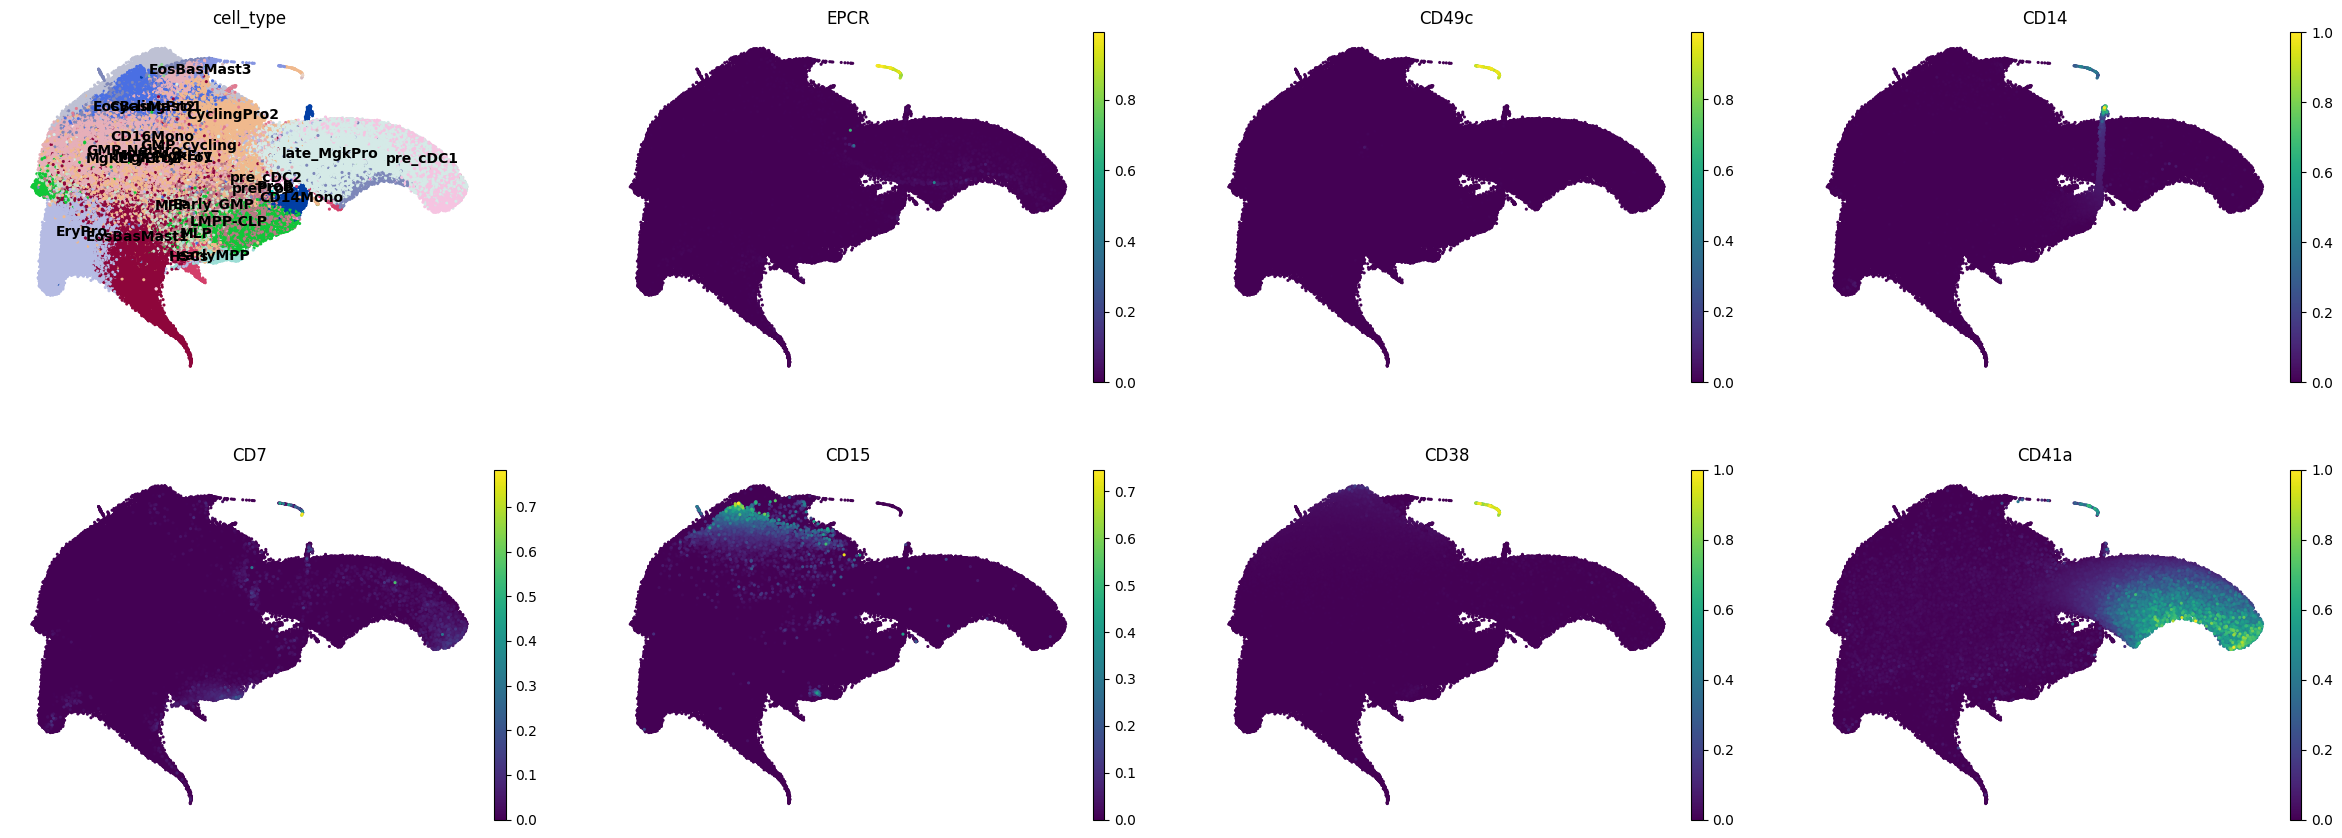

In [14]:
cd1_markers = ["EPCR", "CD49c", "CD14", "CD7", "CD15", "CD38"]
mgk_markers = ["CD41a"]
sc.pl.embedding(adata_loop2, "umap", color=["cell_type"] + cd1_markers + mgk_markers, frameon=False, legend_loc="on data", s=20)


## Get Pre cDC1 Population from Loop 2.

### Subset Adata.

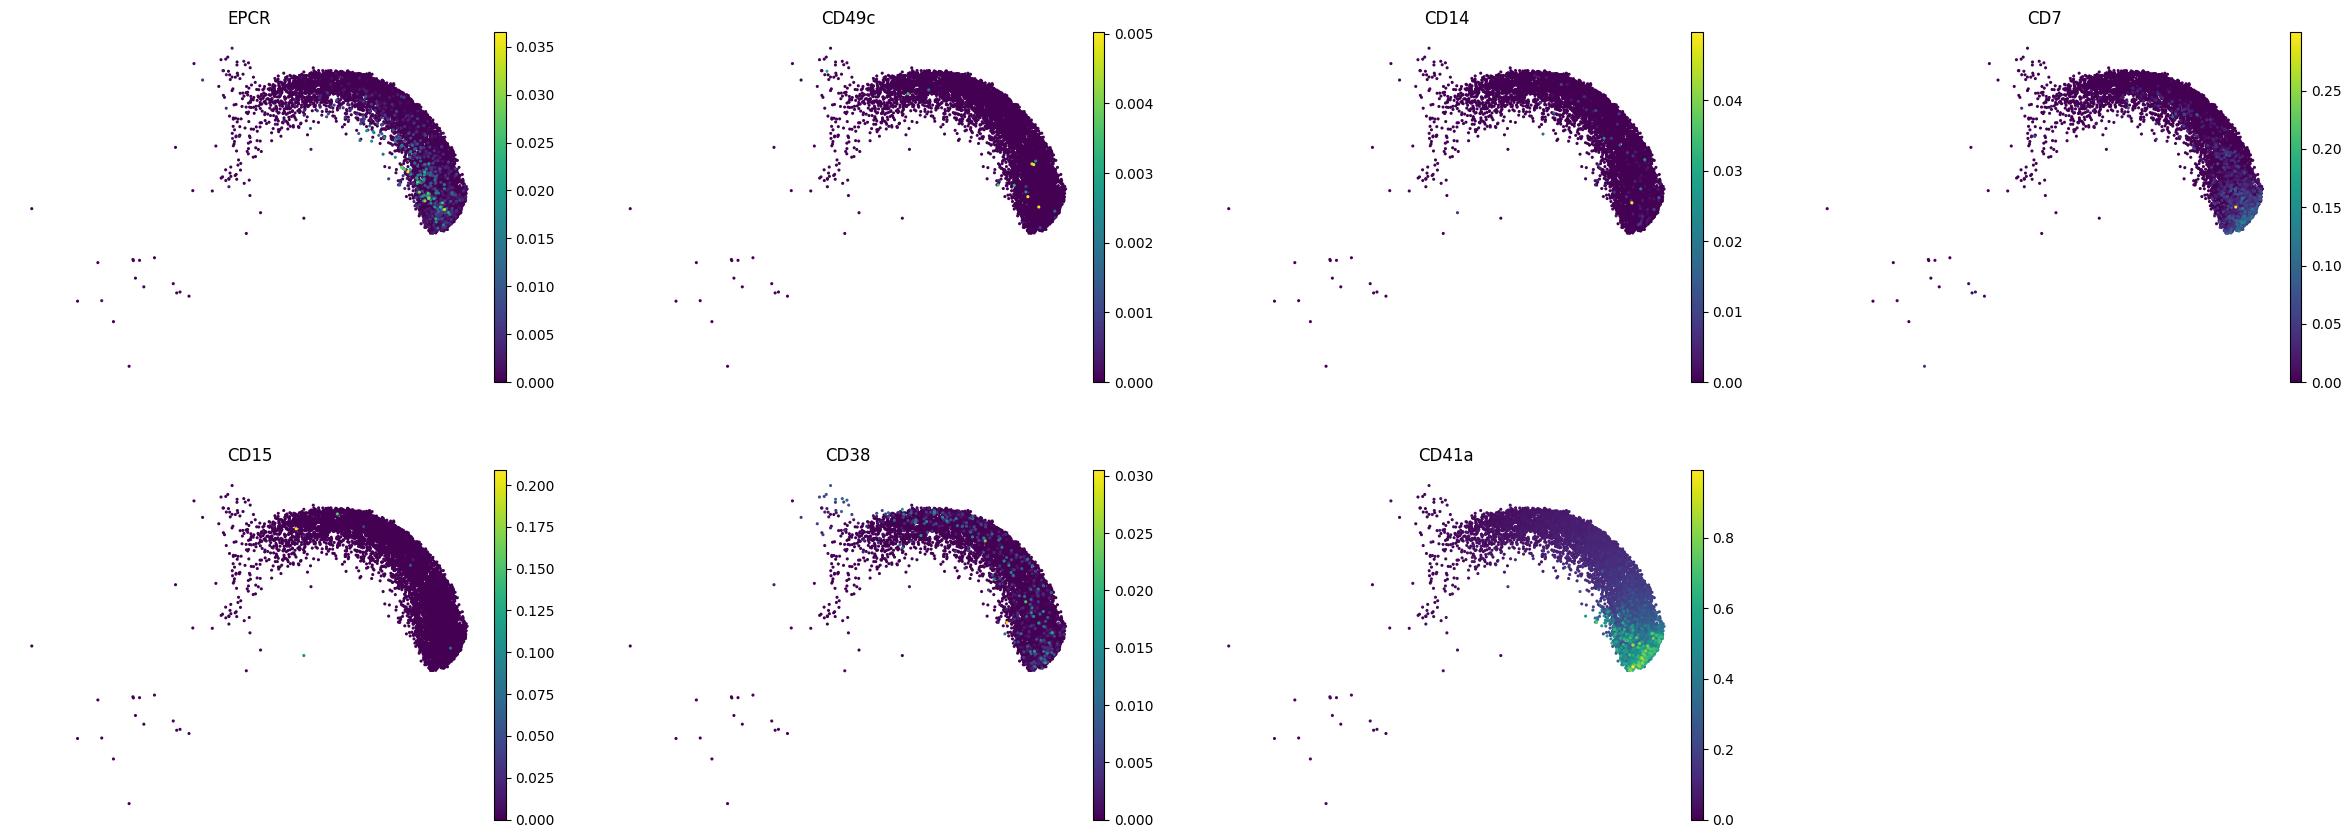

AnnData object with n_obs × n_vars = 7973 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap', 'c

In [15]:
dc1_mask_loop2 = adata_loop2.obs["cell_type"] == "pre_cDC1"
adata_dc1_loop2 = adata_loop2[dc1_mask_loop2].copy()
sc.pl.embedding(adata_dc1_loop2, "umap", color=cd1_markers + mgk_markers, frameon=False, legend_loc="on data", s=20)
adata_dc1_loop2

### Scatter Plot of Markers.

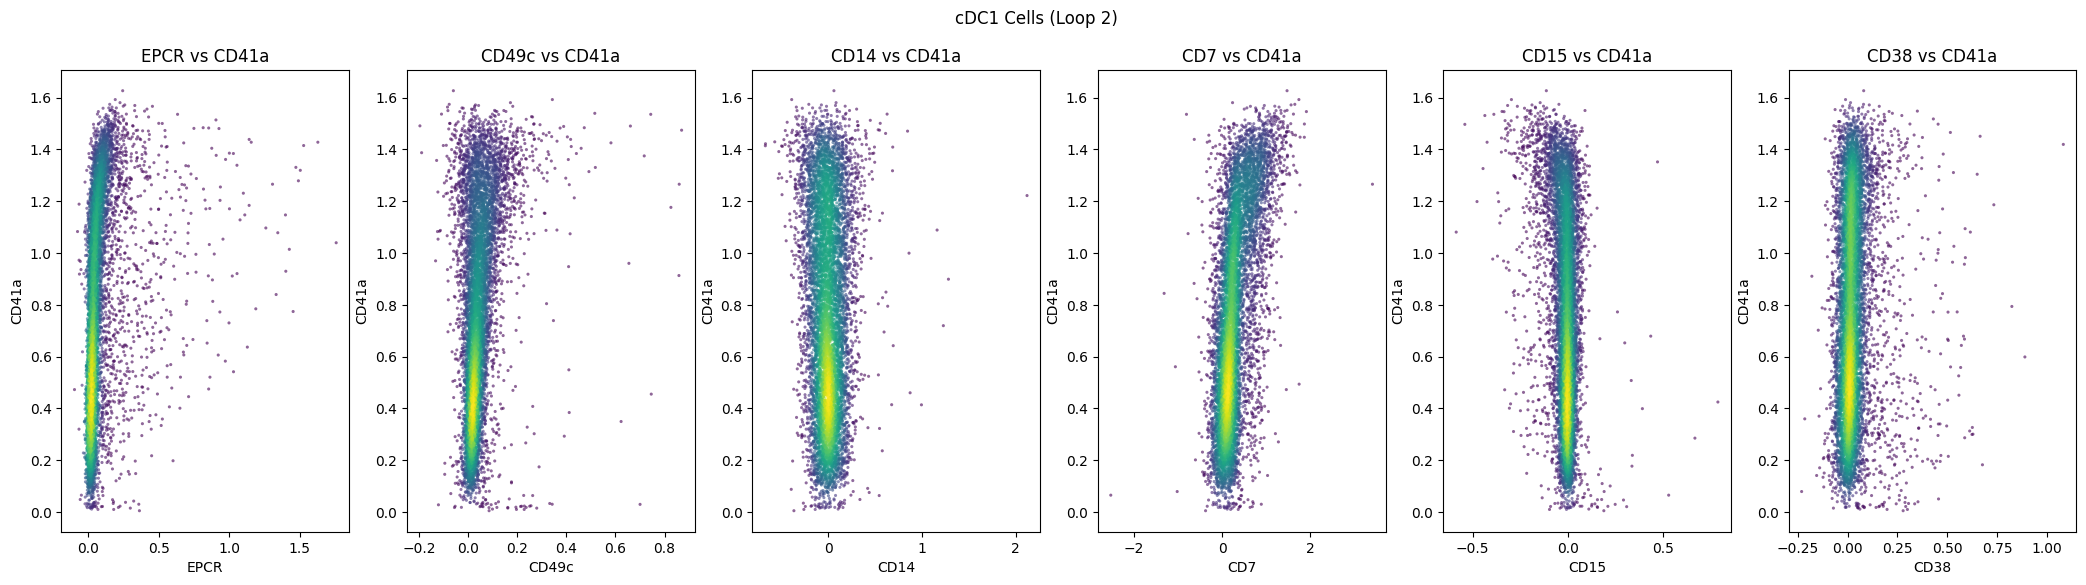

In [16]:
# plot old data
_ = make_scatter_plot(
    adata_dc1_loop2,
    target_markers=mgk_markers,
    ref_markers=cd1_markers,
    title="cDC1 Cells (Loop 2)"
)

### Dot Plot of cDC1 Cells from Loop 2.

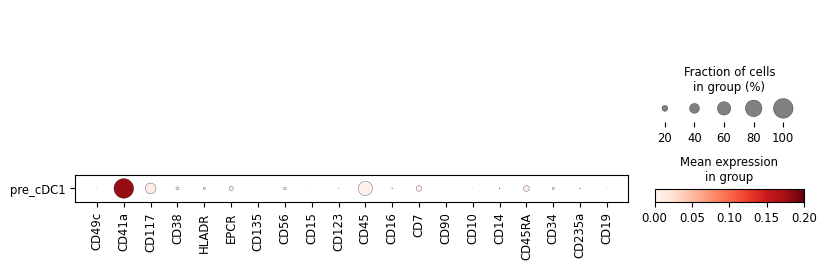

In [17]:
sc.pl.dotplot(
    adata_dc1_loop2,
    adata_dc1_loop2.var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2
)

## Get Pre cDC1 Population from Loop 1.

### Subset Adata.

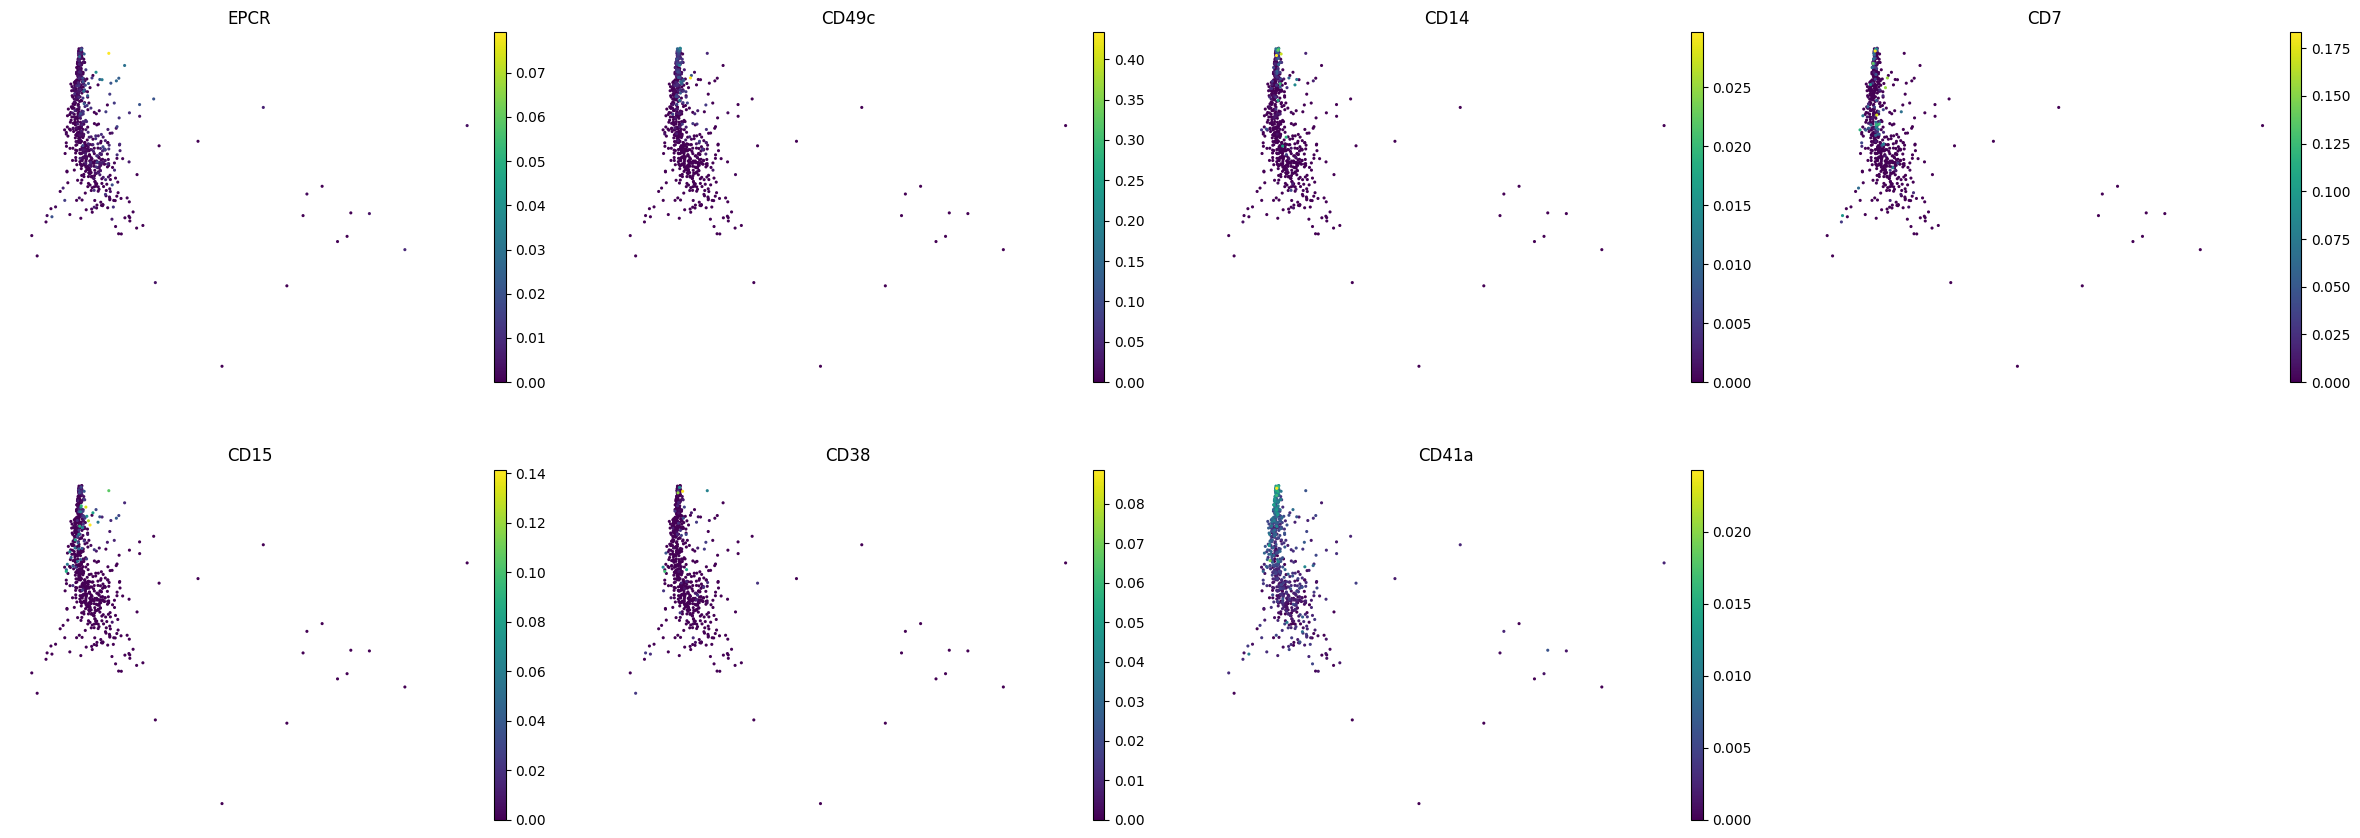

AnnData object with n_obs × n_vars = 704 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old', 'm

In [18]:
dc1_mask_loop1 = adata_loop1.obs["cell_type"] == "pre_cDC1"
adata_dc1_loop1 = adata_loop1[dc1_mask_loop1].copy()
sc.pl.embedding(adata_dc1_loop1, "umap", color=cd1_markers + mgk_markers, frameon=False, legend_loc="on data", s=20)
adata_dc1_loop1

### Scatter Plot of Markers.

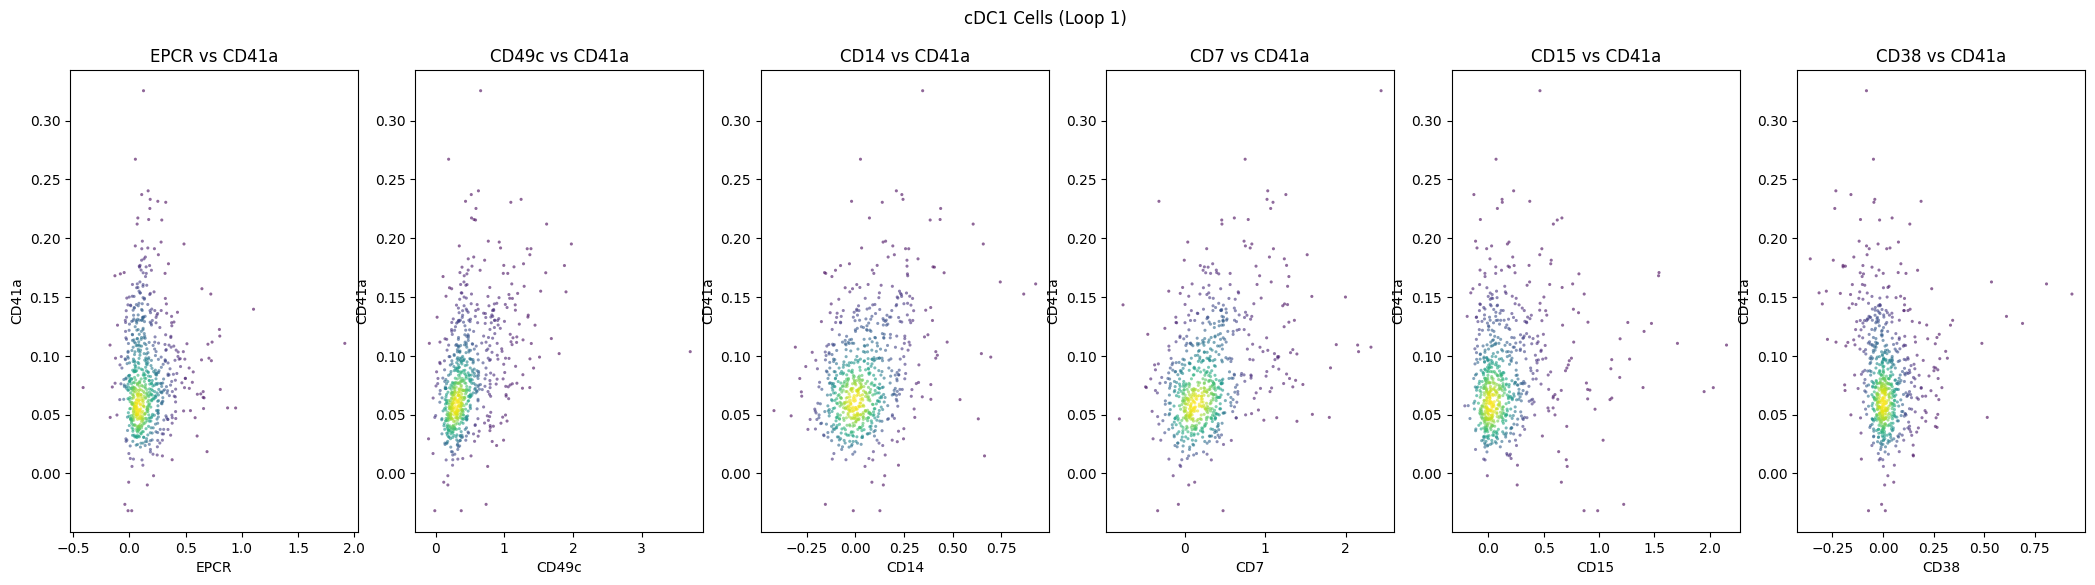

In [19]:
# plot old data
_ = make_scatter_plot(
    adata_dc1_loop1,
    target_markers=mgk_markers,
    ref_markers=cd1_markers,
    title="cDC1 Cells (Loop 1)"
)

### Dot Plot of cDC1 Cells from Loop 1.

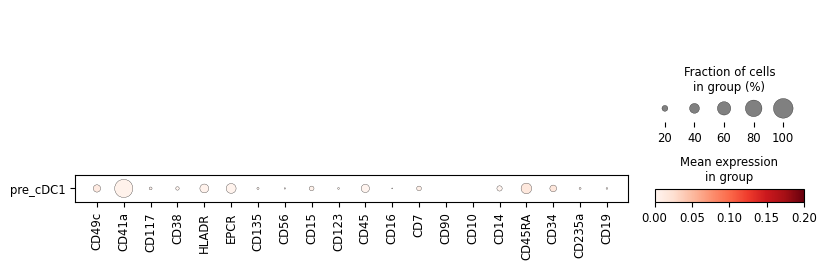

In [20]:
sc.pl.dotplot(
    adata_dc1_loop1,
    adata_dc1_loop2.var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2
)

## Get MgkPro Population from Loop 2.

### Subset Adata.

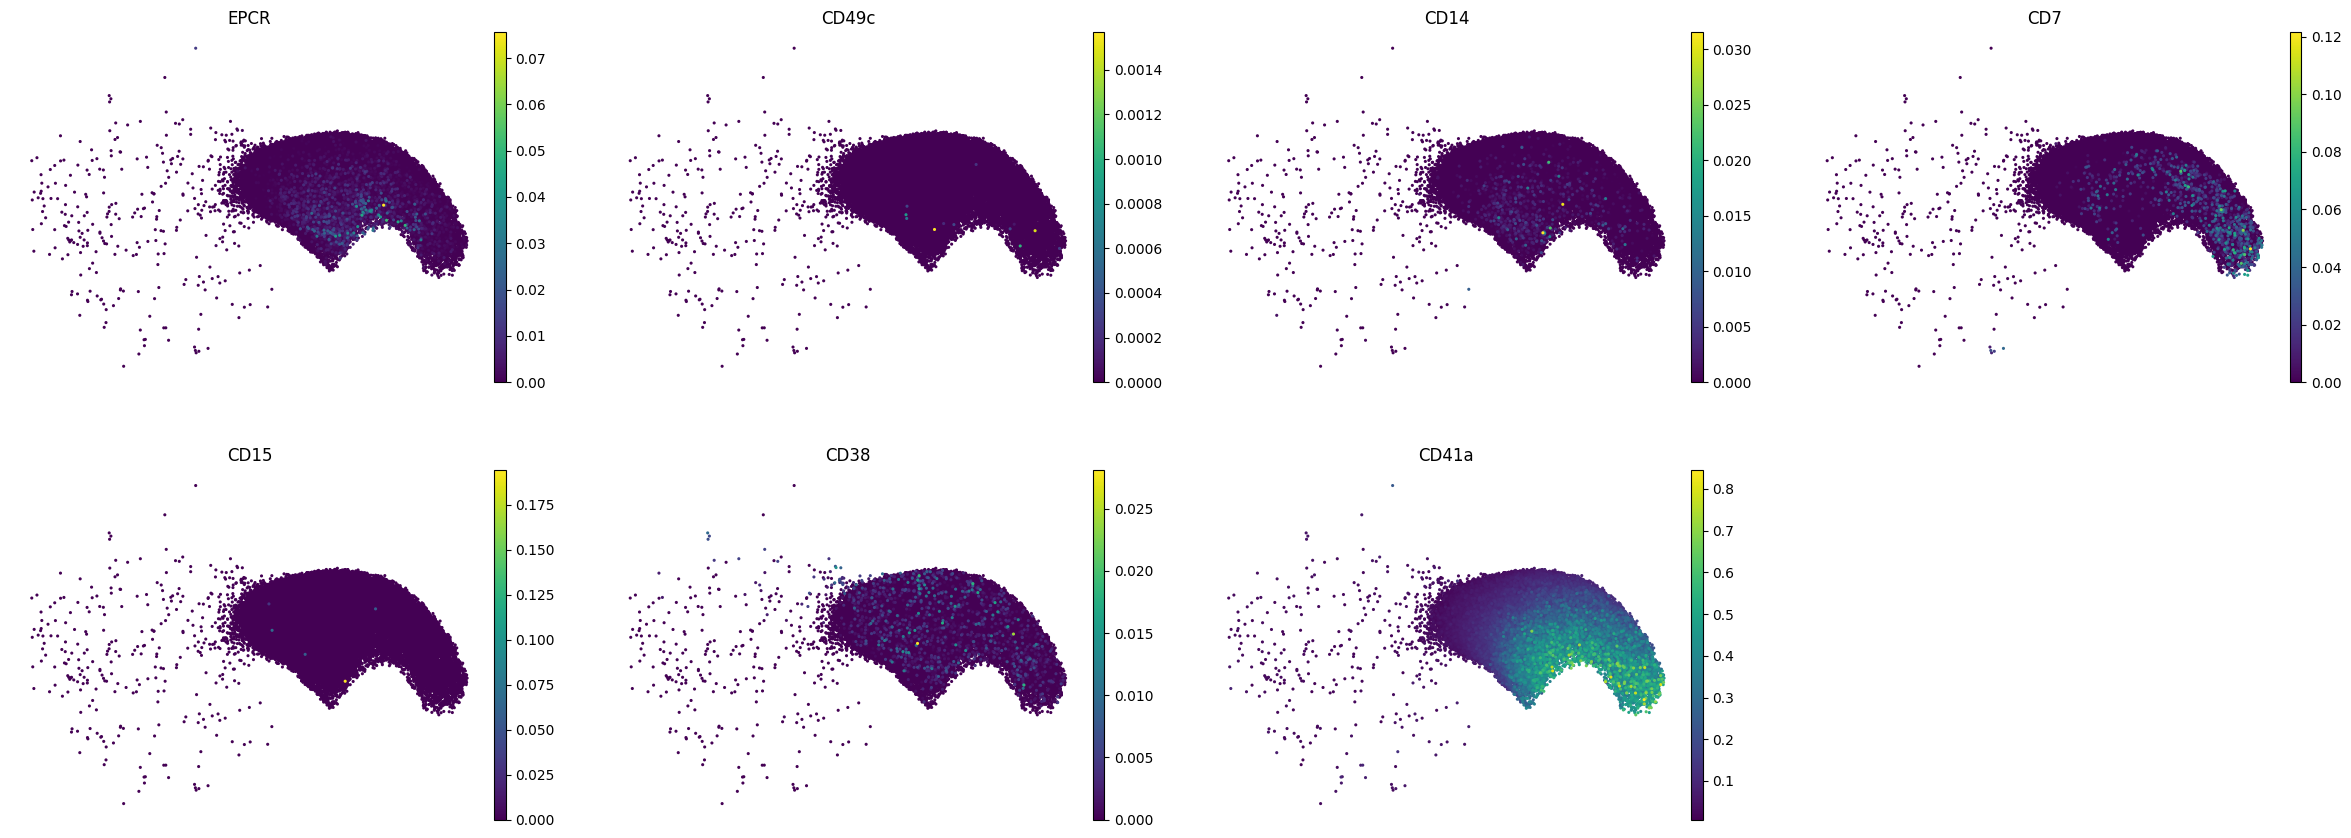

AnnData object with n_obs × n_vars = 39292 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap', '

In [21]:
mgk_mask = adata_loop2.obs["cell_type"] == "late_MgkPro"
adata_mgk_loop2 = adata_loop2[mgk_mask].copy()
sc.pl.embedding(adata_mgk_loop2, "umap", color=cd1_markers + mgk_markers, frameon=False, legend_loc="on data", s=20)
adata_mgk_loop2

### Scatter Plot of Markers.

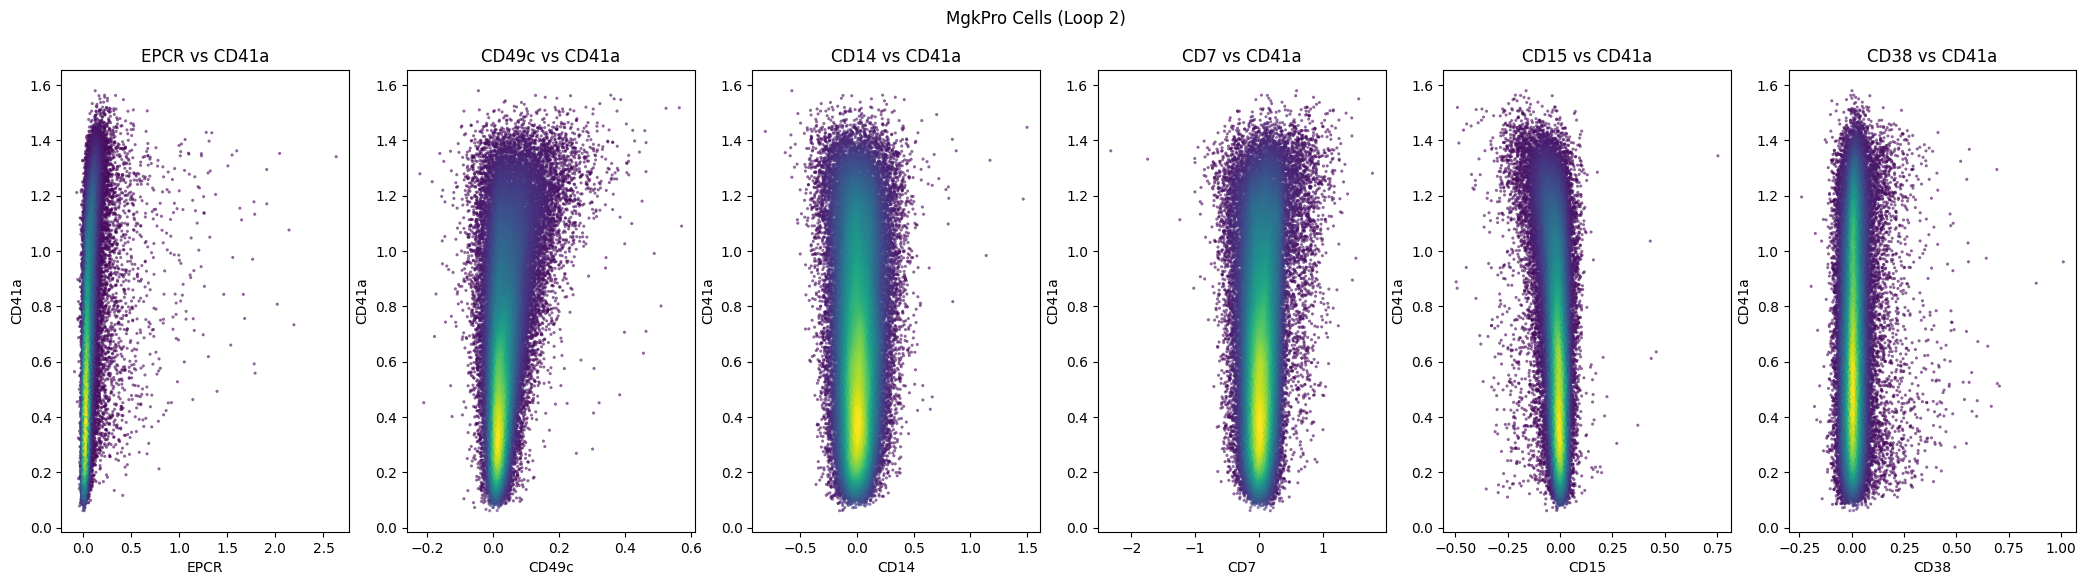

In [22]:
# plot old data
_ = make_scatter_plot(
    adata_mgk_loop2,
    target_markers=mgk_markers,
    ref_markers=cd1_markers,
    title="MgkPro Cells (Loop 2)"
)

## Get MgkPro Population from Loop 1.

### Subset Adata.

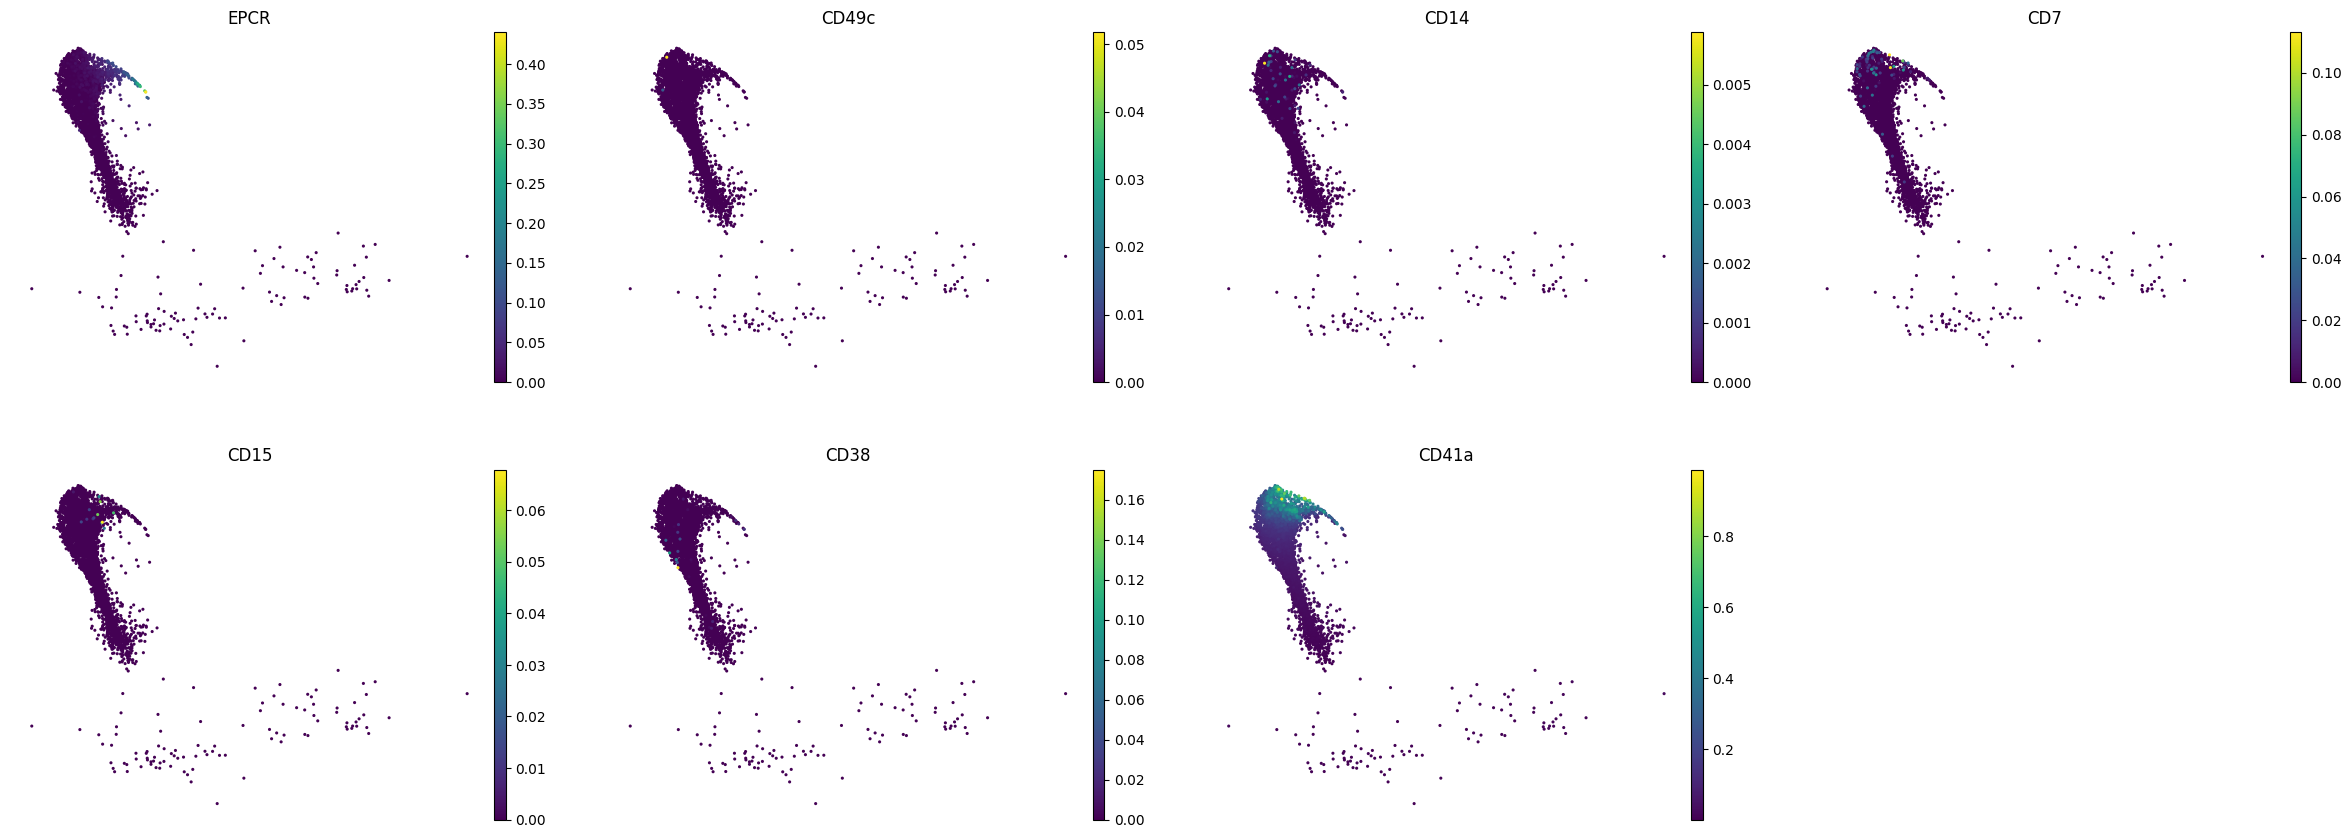

AnnData object with n_obs × n_vars = 4470 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old', '

In [23]:
mgk_mask = adata_loop1.obs["cell_type"] == "late_MgkPro"
adata_mgk_loop1 = adata_loop1[mgk_mask].copy()
sc.pl.embedding(adata_mgk_loop1, "umap", color=cd1_markers + mgk_markers, frameon=False, legend_loc="on data", s=20)
adata_mgk_loop1

### Scatter Plot of Markers.

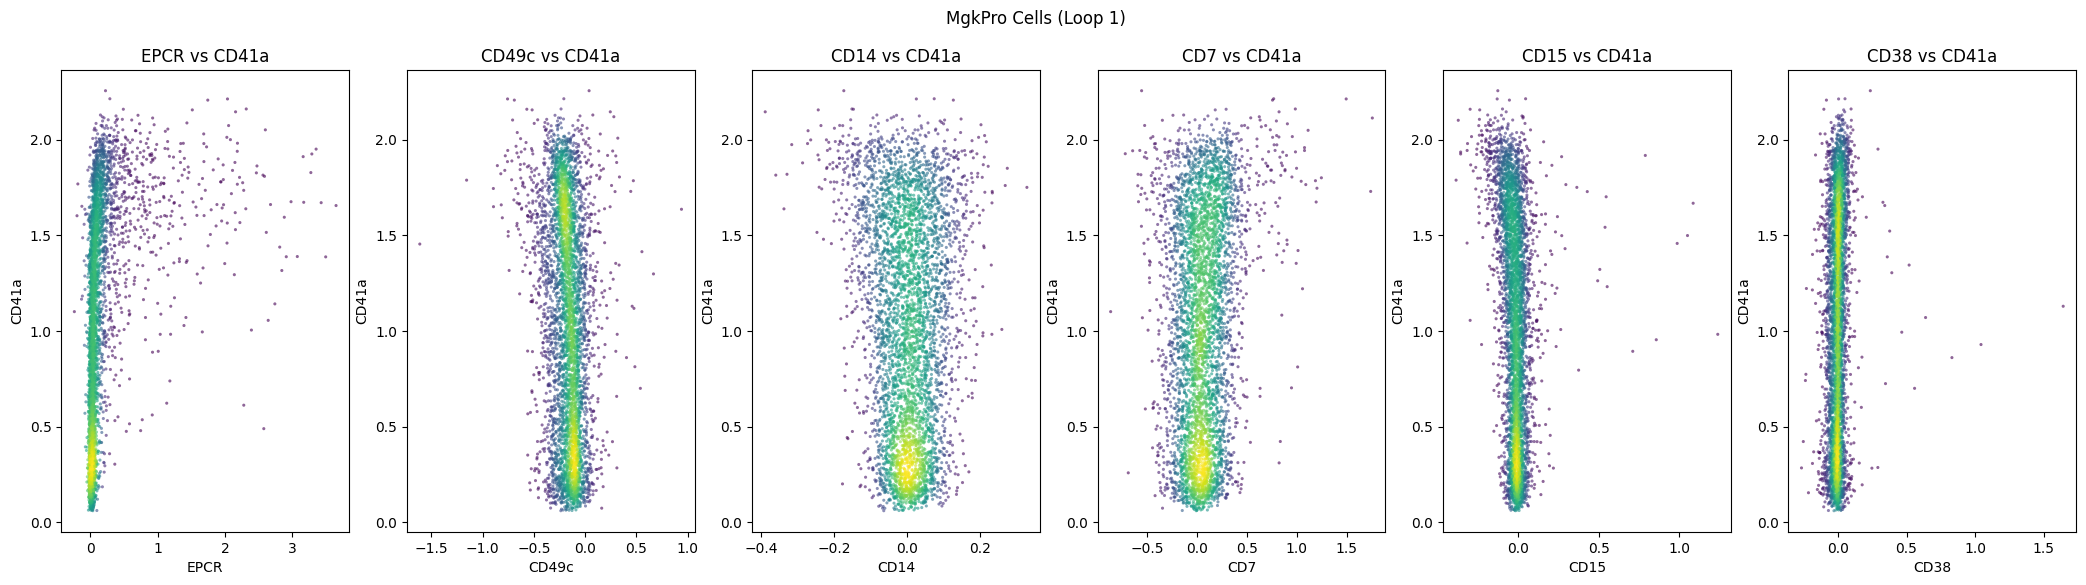

In [24]:
# plot old data
_ = make_scatter_plot(
    adata_mgk_loop1,
    target_markers=mgk_markers,
    ref_markers=cd1_markers,
    title="MgkPro Cells (Loop 1)"
)

## Leiden Clustering on pre-cDC1 (Loop 2).

### Compute Neighborhood Graph.

In [25]:
# neighbors
if "neighbors" not in adata_dc1_loop2.uns.keys():
    sc.pp.neighbors(adata_dc1_loop2)
if "neighbors_100" not in adata_dc1_loop2.uns.keys():
    sc.pp.neighbors(adata_dc1_loop2, n_neighbors=100, key_added="neighbors_100")


### Leiden Cluster with Default Neighbors.

In [26]:
# leiden with default neighbors
if "leiden" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2)
if "leiden_0.75" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.075, key_added="leiden_0.75")
if "leiden_0.5" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.5, key_added="leiden_0.5")
if "leiden_0.1" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.1, key_added="leiden_0.1")

/tmp/ipykernel_2840874/3521102535.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_dc1_loop2)
/tmp/ipykernel_2840874/3521102535.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_dc1_loop2, resolution=0.075, key_added="leiden_0.75")
/tm

### Leiden Clustering with 100 Neighbors (Coarse Clustering).

In [27]:
# leiden with 100 neighbors
if "leiden_n100" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, key_added="leiden_n100", neighbors_key="neighbors_100")
if "leiden_n100_0.75" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.075, key_added="leiden_n100_0.75", neighbors_key="neighbors_100")
if "leiden_n100_0.5" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.5, key_added="leiden_n100_0.5", neighbors_key="neighbors_100")
if "leiden_n100_0.1" not in adata_dc1_loop2.obs.columns:
    sc.tl.leiden(adata_dc1_loop2, resolution=0.1, key_added="leiden_n100_0.1", neighbors_key="neighbors_100")


/tmp/ipykernel_2840874/3878321603.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_dc1_loop2, key_added="leiden_n100", neighbors_key="neighbors_100")


/tmp/ipykernel_2840874/3878321603.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_dc1_loop2, resolution=0.075, key_added="leiden_n100_0.75", neighbors_key="neighbors_100")
/tmp/ipykernel_2840874/3878321603.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.

### Visualize Resulting Clusters on UMAP Space.

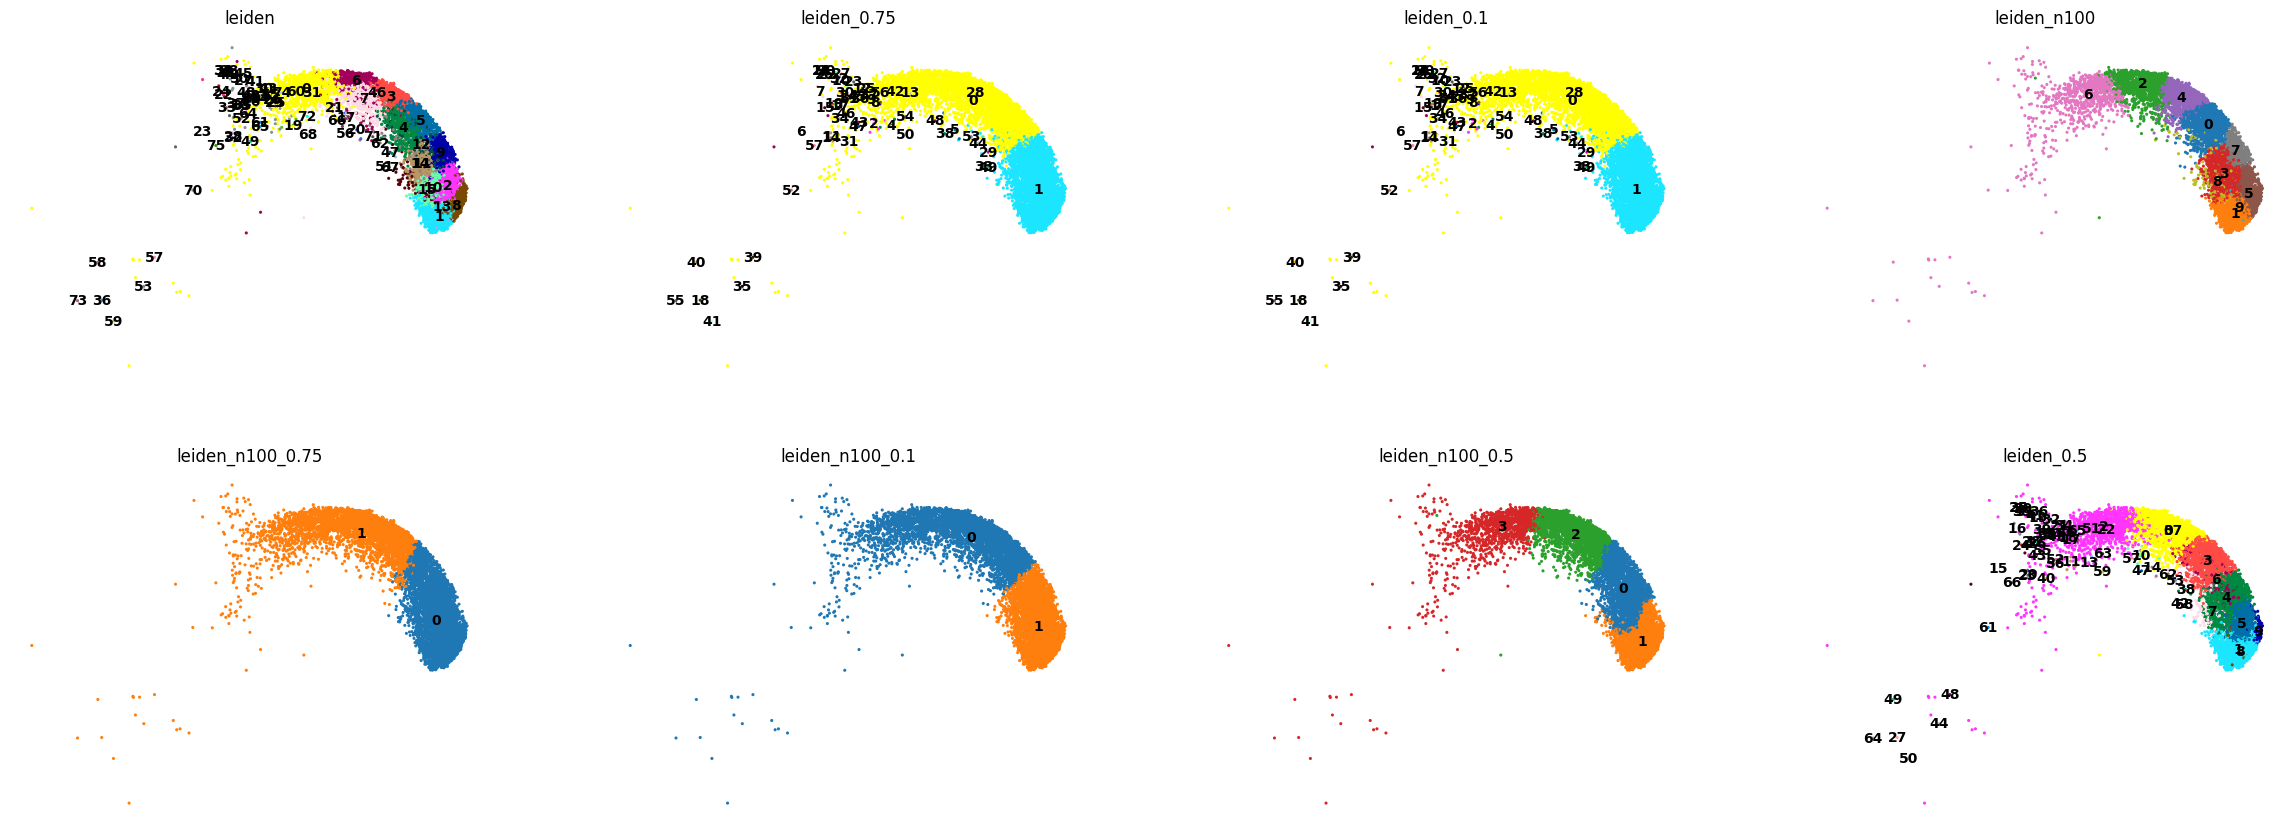

AnnData object with n_obs × n_vars = 7973 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden', 'leiden_0.75', 'leiden_0.5', 'leiden_0.1', 'leiden_n100', 'leiden_n100_0.75', 'leiden_n100_0.5', 'leiden_n100_0.1'
    var: 'n', 'channel'

In [28]:
color = [
    "leiden", "leiden_0.75", "leiden_0.1", 
    "leiden_n100", "leiden_n100_0.75", "leiden_n100_0.1",
    "leiden_n100_0.5", "leiden_0.5",
]
sc.pl.embedding(adata_dc1_loop2, "umap", color=color, frameon=False, legend_loc="on data", s=20)
adata_dc1_loop2

### Dotplot per Leiden Clustering.

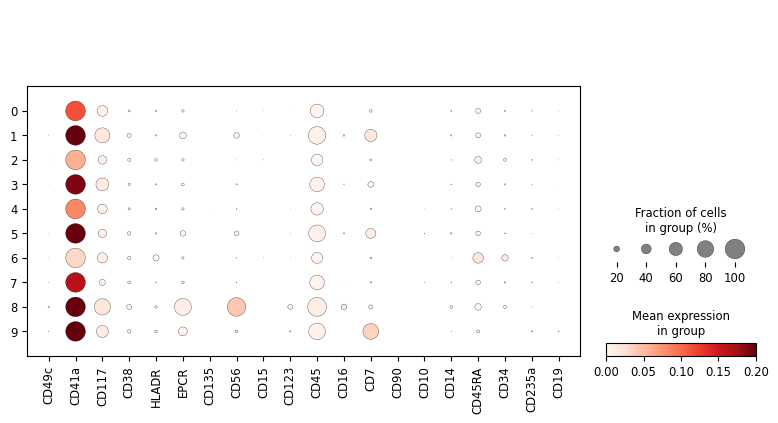

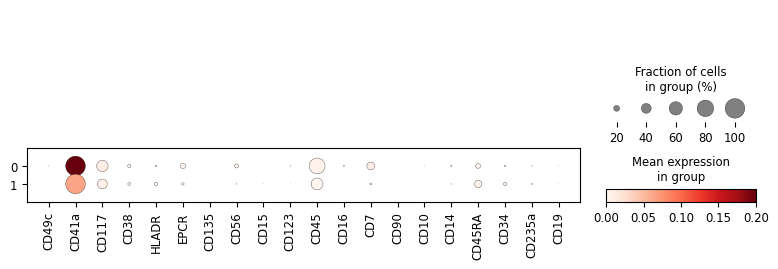

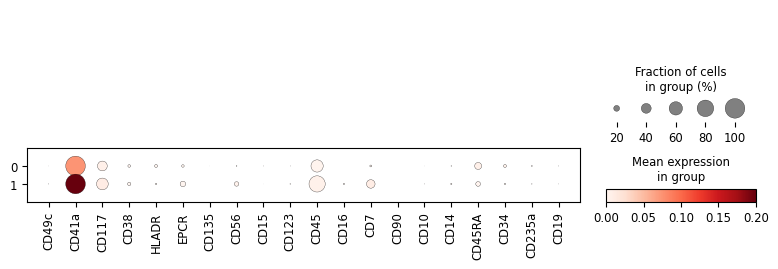

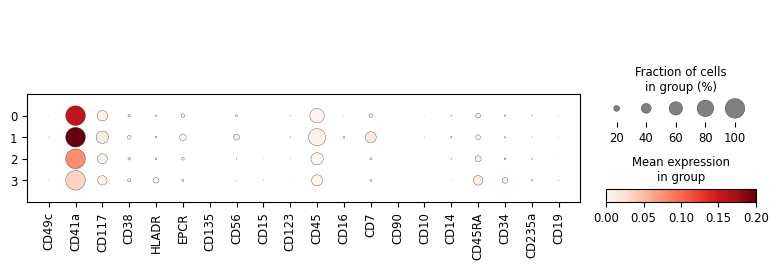

In [29]:
leiden_settings_for_dotplot = [
    "leiden_n100", "leiden_n100_0.75",
    "leiden_n100_0.1", "leiden_n100_0.5", 
]
for leiden_col in leiden_settings_for_dotplot:
    sc.pl.dotplot(
        adata_dc1_loop2,
        adata_dc1_loop2.var_names,
        leiden_col,
        vmin=0.0,
        vmax=0.2
    )
